# 01a — v1.0-trainval Metadata-Only EDA
## Multi-Attribute Scene Classification on nuScenes

**Purpose:** Lightweight metadata-only exploration of v1.0-trainval to answer the planning question:

> **Will scaling from v1.0-mini (10 scenes) to v1.0-trainval (~850 scenes) solve Stage 1's diagnosed problems?**

### Specific questions

1. How many scenes contain rain? (Stage 1 problem: rain in 1-2 mini scenes)
2. How many scenes are night?
3. Is the 150-scene stratified subset feasible?
4. Geographic / location distribution?

### Scope

**Metadata-only.** No image loading, no feature extraction, no forward-cone object counts (deferred to `01b`). Runtime: ~1-2 minutes.

### Reproducibility

The notebook auto-detects the nuScenes metadata location regardless of how it was extracted from the official ZIP. Markers don't need to rename folders.


## 0. Setup

In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Standard imports OK')

Standard imports OK


## 0.1 Locate Project Root

Works regardless of where Jupyter was launched from.

In [3]:
def find_project_root():
    """Walk up cwd until we find a folder containing README.md and notebooks/."""
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError(
        f'Could not find project root from {p}. '
        f'Looking for a parent containing both README.md and notebooks/'
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 0.2 Auto-Detect nuScenes Metadata Location

Different ZIP extractors and download tools produce different folder structures:

| Layout | Where metadata ends up |
|---|---|
| Manual unzip into a flat folder | `data/nuscenes/v1.0-trainval/v1.0-trainval/*.json` |
| Extraction tool with wrapper folder | `data/nuscenes/v1.0-trainval/v1.0-trainval_meta/v1.0-trainval/*.json` |
| Direct extraction at parent | `data/nuscenes/v1.0-trainval/*.json` (rare) |

This cell searches the common layouts and finds whichever exists. **No manual folder renaming required.**

In [4]:
DATASET_VERSION = 'v1.0-trainval'

def find_nuscenes_dataroot(base_dir, version, min_json_files=10):
    """Auto-detect the correct dataroot for the nuScenes devkit.

    The devkit expects {dataroot}/{version}/*.json with ~13 metadata files.
    This function tries several common layouts produced by different ZIP
    extractors and returns the first one with enough JSON files.

    Returns: tuple(dataroot_path, found_metadata_dir)
    """
    candidates = [
        base_dir,                              # base/{version}/*.json
        base_dir / f'{version}_meta',          # base/{version}_meta/{version}/*.json
        base_dir.parent,                       # base.parent/{version}/*.json
    ]

    for candidate in candidates:
        if not candidate.exists():
            continue
        metadata_dir = candidate / version
        if metadata_dir.exists():
            json_files = list(metadata_dir.glob('*.json'))
            if len(json_files) >= min_json_files:
                return candidate, metadata_dir

    msg = (
        f'Could not find nuScenes {version} metadata.\n'
        f'Searched (each must contain {version}/*.json with >={min_json_files} files):\n'
    )
    for c in candidates:
        msg += f'  - {c}\n'
    msg += (
        f'\nFix: ensure the {version} metadata ZIP has been extracted into '
        f'data/nuscenes/{version}/ (any common layout works).'
    )
    raise FileNotFoundError(msg)

NUSCENES_BASE = Path('data/nuscenes') / DATASET_VERSION
DATAROOT, METADATA_DIR = find_nuscenes_dataroot(NUSCENES_BASE, DATASET_VERSION)

print(f'✓ Detected nuScenes dataroot: {DATAROOT}')
print(f'✓ Metadata location:          {METADATA_DIR}')
print(f'✓ JSON files found:           {len(list(METADATA_DIR.glob("*.json")))}')

✓ Detected nuScenes dataroot: data\nuscenes\v1.0-trainval\v1.0-trainval_meta
✓ Metadata location:          data\nuscenes\v1.0-trainval\v1.0-trainval_meta\v1.0-trainval
✓ JSON files found:           13


## 1. Load nuScenes Metadata

In [5]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version=DATASET_VERSION,
                dataroot=str(DATAROOT),
                verbose=True)
print(f'\n✓ Loaded {len(nusc.scene)} scenes')
print(f'✓ Loaded {len(nusc.sample)} keyframes')
print(f'✓ Loaded {len(nusc.log)} logs')

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 13.020 seconds.
Reverse indexing ...
Done reverse indexing in 7.3 seconds.

✓ Loaded 850 scenes
✓ Loaded 34149 keyframes
✓ Loaded 68 logs


## 2. Output Directories

In [6]:
RESULTS_DIR  = Path('results') / DATASET_VERSION / 'metrics'
FIG_DIR      = Path('results') / DATASET_VERSION / 'figures'
META_OUT_DIR = Path('data/processed') / DATASET_VERSION / 'metadata'

for p in [RESULTS_DIR, FIG_DIR, META_OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'RESULTS_DIR  = {RESULTS_DIR}')
print(f'FIG_DIR      = {FIG_DIR}')
print(f'META_OUT_DIR = {META_OUT_DIR}')

RESULTS_DIR  = results\v1.0-trainval\metrics
FIG_DIR      = results\v1.0-trainval\figures
META_OUT_DIR = data\processed\v1.0-trainval\metadata


## 3. Scene-Level Metadata Extraction

In [7]:
scene_rows = []
for scene in nusc.scene:
    log = nusc.get('log', scene['log_token'])
    scene_rows.append({
        'scene_token': scene['token'],
        'scene_name':  scene['name'],
        'description': scene['description'],
        'location':    log['location'],
        'n_samples':   scene['nbr_samples'],
        'log_token':   scene['log_token'],
    })

df_scenes = pd.DataFrame(scene_rows)
print(f'Total scenes: {len(df_scenes)}')
print(f'Total keyframes (sum across scenes): {df_scenes["n_samples"].sum()}')

Total scenes: 850
Total keyframes (sum across scenes): 34149


In [8]:
print('Locations (cities):')
print(df_scenes['location'].value_counts())
print()
print('Sample count per scene:')
print(df_scenes['n_samples'].describe())

Locations (cities):
location
boston-seaport              467
singapore-onenorth          183
singapore-queenstown        115
singapore-hollandvillage     85
Name: count, dtype: int64

Sample count per scene:
count    850.000000
mean      40.175294
std        0.668033
min       32.000000
25%       40.000000
50%       40.000000
75%       41.000000
max       41.000000
Name: n_samples, dtype: float64


## 4. Parse Time-of-Day from Descriptions

In [9]:
def parse_time_of_day(desc):
    return 'night' if 'night' in desc.lower() else 'day'

df_scenes['time_of_day'] = df_scenes['description'].apply(parse_time_of_day)

print('Time-of-day distribution (scenes):')
print(df_scenes['time_of_day'].value_counts())
print()
day_pct = (df_scenes['time_of_day'] == 'day').mean() * 100
night_pct = (df_scenes['time_of_day'] == 'night').mean() * 100
print(f'  day:   {day_pct:.1f}%')
print(f'  night: {night_pct:.1f}%')

Time-of-day distribution (scenes):
time_of_day
day      751
night     99
Name: count, dtype: int64

  day:   88.4%
  night: 11.6%


## 5. Parse Weather from Descriptions

In [10]:
def parse_weather(desc):
    d = desc.lower()
    return 'rain' if ('rain' in d or 'wet' in d) else 'clear'

df_scenes['weather'] = df_scenes['description'].apply(parse_weather)

print('Weather distribution (scenes):')
print(df_scenes['weather'].value_counts())
print()
clear_pct = (df_scenes['weather'] == 'clear').mean() * 100
rain_pct  = (df_scenes['weather'] == 'rain').mean() * 100
print(f'  clear: {clear_pct:.1f}%')
print(f'  rain:  {rain_pct:.1f}%')

Weather distribution (scenes):
weather
clear    685
rain     165
Name: count, dtype: int64

  clear: 80.6%
  rain:  19.4%


## 6. Joint Distribution (Time × Weather) — THE KEY TABLE

In [11]:
print('=== Joint distribution (scenes) ===')
joint = pd.crosstab(df_scenes['time_of_day'], df_scenes['weather'], margins=True)
print(joint)
print()

joint_clean = pd.crosstab(df_scenes['time_of_day'], df_scenes['weather'])

print('=== Joint distribution as percentage ===')
joint_pct = (joint_clean / len(df_scenes) * 100).round(1)
print(joint_pct)

=== Joint distribution (scenes) ===
weather      clear  rain  All
time_of_day                  
day            602   149  751
night           83    16   99
All            685   165  850

=== Joint distribution as percentage ===
weather      clear  rain
time_of_day             
day           70.8  17.5
night          9.8   1.9


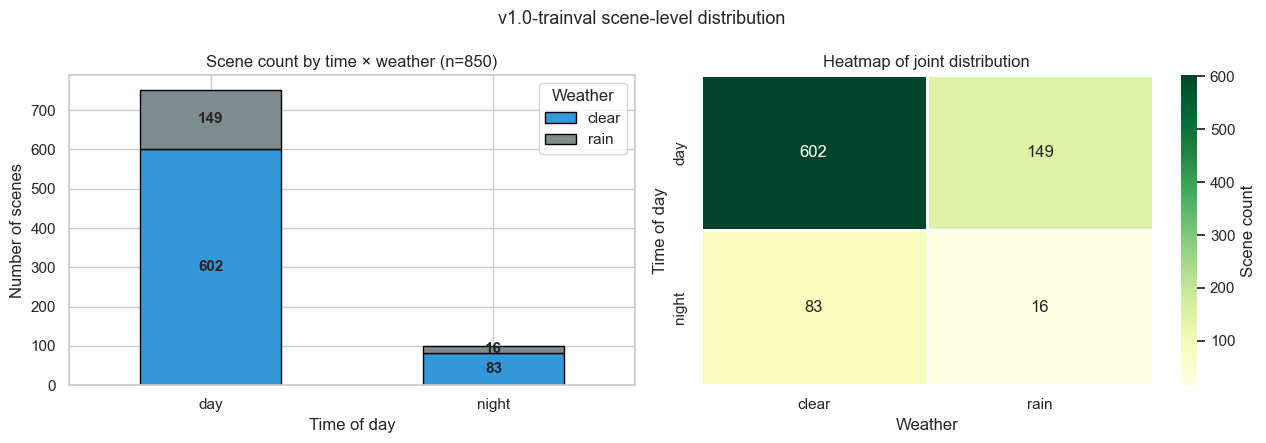

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

joint_clean.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#3498db', '#7f8c8d'], edgecolor='black')
axes[0].set_title(f'Scene count by time × weather (n={len(df_scenes)})')
axes[0].set_ylabel('Number of scenes')
axes[0].set_xlabel('Time of day')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Weather')
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='center', fontsize=11, fontweight='bold')

sns.heatmap(joint_clean, annot=True, fmt='d', cmap='YlGn',
            ax=axes[1], cbar_kws={'label': 'Scene count'}, linewidths=1)
axes[1].set_title('Heatmap of joint distribution')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Time of day')

plt.suptitle('v1.0-trainval scene-level distribution', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'scene_joint_distribution.png', bbox_inches='tight')
plt.show()

## 7. Per-Keyframe Distribution

In [13]:
kf_rows = []
scene_lookup = df_scenes.set_index('scene_token')[['time_of_day', 'weather', 'location']].to_dict('index')
for sample in nusc.sample:
    sc = scene_lookup[sample['scene_token']]
    kf_rows.append({
        'sample_token': sample['token'],
        'scene_token':  sample['scene_token'],
        'time_of_day':  sc['time_of_day'],
        'weather':      sc['weather'],
        'location':     sc['location'],
        'timestamp':    sample['timestamp'],
    })

df_kf = pd.DataFrame(kf_rows)
print(f'Total keyframes: {len(df_kf)}')
print()
print('Keyframe joint distribution:')
print(pd.crosstab(df_kf['time_of_day'], df_kf['weather'], margins=True))

Total keyframes: 34149

Keyframe joint distribution:
weather      clear  rain    All
time_of_day                    
day          24134  6028  30162
night         3345   642   3987
All          27479  6670  34149


## 8. Subset Feasibility Check — THE KEY DECISION

In [14]:
# ── Subset sizing (single source of truth) ─────────────────────────────────
# Change SUBSET_SIZE alone to rescale the whole feasibility check.
SUBSET_SIZE = 150

# Desired balance — same proportions as the original 75-scene plan
# (60% day/clear, ~13% day/rain, 20% night/clear, ~7% night/rain).
TARGET_PROPORTIONS = {
    ('day',   'clear'): 0.60,
    ('day',   'rain'):  0.1333,
    ('night', 'clear'): 0.20,
    ('night', 'rain'):  0.0667,
}

# Proportional targets = the "ideal" ask, before considering availability.
target_strata = {k: round(p * SUBSET_SIZE) for k, p in TARGET_PROPORTIONS.items()}
# Absorb any rounding drift in the largest stratum so totals hit SUBSET_SIZE.
target_strata[('day', 'clear')] += SUBSET_SIZE - sum(target_strata.values())

print('=' * 75)
print(f'SUBSET FEASIBILITY CHECK  (proportional target = {SUBSET_SIZE} scenes)')
print('=' * 75)
print()
print(f'{"Stratum":<20} {"Target":>8} {"Available":>12} {"Status":>30}')
print('-' * 75)

feasibility_rows = []
all_feasible = True
for (tod, wx), target in target_strata.items():
    available = len(df_scenes[(df_scenes['time_of_day'] == tod) &
                               (df_scenes['weather'] == wx)])
    if available >= target:
        status = '✓ feasible'
    else:
        status = f'⚠️ short by {target - available}'
        all_feasible = False
    feasibility_rows.append({
        'time_of_day': tod, 'weather': wx,
        'target': target, 'available': available,
        'feasible': available >= target,
    })
    print(f'{tod + "/" + wx:<20} {target:>8} {available:>12} {status:>30}')

print('-' * 75)
total_target = sum(target_strata.values())
total_available = sum(r['available'] for r in feasibility_rows)
print(f'{"TOTAL":<20} {total_target:>8} {total_available:>12}')
print()

if all_feasible:
    print(f'✓ ALL STRATA FEASIBLE — proportional {SUBSET_SIZE}-scene subset is achievable')
else:
    print('⚠️ SOME STRATA SHORT (expected: rain is the binding constraint)')
    print('   → see the availability-adjusted allocation in the next cell')

SUBSET FEASIBILITY CHECK  (proportional target = 150 scenes)

Stratum                Target    Available                         Status
---------------------------------------------------------------------------
day/clear                  90          602                     ✓ feasible
day/rain                   20          149                     ✓ feasible
night/clear                30           83                     ✓ feasible
night/rain                 10           16                     ✓ feasible
---------------------------------------------------------------------------
TOTAL                     150          850

✓ ALL STRATA FEASIBLE — proportional 150-scene subset is achievable


In [15]:
# ── Availability-adjusted allocation ───────────────────────────────────────
# We can't select rain scenes that don't exist. If a rare stratum is short,
# take ALL of it and redistribute the deficit onto strata with headroom
# (clear scenes are plentiful), so the subset still reaches SUBSET_SIZE.
available_per_stratum = {
    (r['time_of_day'], r['weather']): r['available'] for r in feasibility_rows
}

adjusted = dict(target_strata)
deficit = 0
for key, want in target_strata.items():           # cap each stratum at availability
    have = available_per_stratum[key]
    if want > have:
        deficit += want - have
        adjusted[key] = have

for key in sorted(adjusted, key=lambda k: -available_per_stratum[k]):  # fill, largest first
    if deficit <= 0:
        break
    headroom = available_per_stratum[key] - adjusted[key]
    take = min(headroom, deficit)
    adjusted[key] += take
    deficit -= take

adjusted_total = sum(adjusted.values())
print('AVAILABILITY-ADJUSTED ALLOCATION')
print('-' * 75)
print(f'{"Stratum":<20} {"Proportional":>13} {"Adjusted":>10} {"Available":>11}')
print('-' * 75)
for key in target_strata:
    tod, wx = key
    print(f'{tod + "/" + wx:<20} {target_strata[key]:>13} {adjusted[key]:>10} {available_per_stratum[key]:>11}')
print('-' * 75)
print(f'{"TOTAL":<20} {sum(target_strata.values()):>13} {adjusted_total:>10}')
print()

if deficit > 0:
    print(f'⚠️ Even taking every available scene, the balanced subset falls {deficit} short of {SUBSET_SIZE}.')
    print(f'   Largest feasible balanced subset ≈ {adjusted_total} scenes.')
else:
    print(f'✓ A feasible {SUBSET_SIZE}-scene subset is achievable with the ADJUSTED quotas above.')
print()
print('→ Use `adjusted` (not `target_strata`) as the per-stratum quotas in the')
print('  scene-selection notebook. `target_strata` records the ideal proportional intent.')

AVAILABILITY-ADJUSTED ALLOCATION
---------------------------------------------------------------------------
Stratum               Proportional   Adjusted   Available
---------------------------------------------------------------------------
day/clear                       90         90         602
day/rain                        20         20         149
night/clear                     30         30          83
night/rain                      10         10          16
---------------------------------------------------------------------------
TOTAL                          150        150

✓ A feasible 150-scene subset is achievable with the ADJUSTED quotas above.

→ Use `adjusted` (not `target_strata`) as the per-stratum quotas in the
  scene-selection notebook. `target_strata` records the ideal proportional intent.


## 9. Comparison with v1.0-mini

Auto-detects v1.0-mini metadata location too.

In [16]:
# Try multiple paths for v1.0-mini metadata
mini_candidates = [
    Path('data/processed/v1.0-mini/metadata/sample_metadata_enriched.csv'),
    Path('data/metadata/sample_metadata_enriched.csv'),
    Path('data/processed/v1.0-mini/metadata/sample_metadata.csv'),
]
mini_kf_df = None
for p in mini_candidates:
    if p.exists():
        mini_kf_df = pd.read_csv(p)
        print(f'✓ Loaded v1.0-mini metadata: {p} ({len(mini_kf_df)} rows)')
        break

if mini_kf_df is None:
    print('v1.0-mini metadata not found — comparison uses known values from Stage 1 runs')

✓ Loaded v1.0-mini metadata: data\processed\v1.0-mini\metadata\sample_metadata_enriched.csv (404 rows)


In [17]:
comp_rows = []

if mini_kf_df is not None:
    n_mini_scenes = (mini_kf_df['scene_name'].nunique() if 'scene_name' in mini_kf_df.columns
                      else (mini_kf_df['scene_token'].nunique() if 'scene_token' in mini_kf_df.columns else 10))
    n_mini_kf = len(mini_kf_df)
    mini_night_kf = ((mini_kf_df['time_of_day'] == 'night').sum() if 'time_of_day' in mini_kf_df.columns else 'N/A')
    mini_rain_kf  = ((mini_kf_df['weather'] == 'rain').sum()       if 'weather' in mini_kf_df.columns else 'N/A')
else:
    n_mini_scenes = 10
    n_mini_kf = 404
    mini_night_kf = '~121'
    mini_rain_kf = '40'

n_trainval_scenes     = len(df_scenes)
n_trainval_kf         = len(df_kf)
trainval_night_kf     = (df_kf['time_of_day'] == 'night').sum()
trainval_rain_kf      = (df_kf['weather'] == 'rain').sum()
trainval_night_scenes = (df_scenes['time_of_day'] == 'night').sum()
trainval_rain_scenes  = (df_scenes['weather'] == 'rain').sum()

comp_rows = [
    {'Statistic': 'Scenes',          'v1.0-mini': n_mini_scenes,  'v1.0-trainval': n_trainval_scenes, 'Scale-up': f'{n_trainval_scenes / max(n_mini_scenes, 1):.1f}x'},
    {'Statistic': 'Keyframes',       'v1.0-mini': n_mini_kf,      'v1.0-trainval': n_trainval_kf,     'Scale-up': f'{n_trainval_kf / max(n_mini_kf, 1):.1f}x'},
    {'Statistic': 'Night scenes',    'v1.0-mini': 3,               'v1.0-trainval': int(trainval_night_scenes), 'Scale-up': '—'},
    {'Statistic': 'Rain scenes',     'v1.0-mini': 1,               'v1.0-trainval': int(trainval_rain_scenes),  'Scale-up': '—'},
    {'Statistic': 'Night keyframes', 'v1.0-mini': mini_night_kf,  'v1.0-trainval': int(trainval_night_kf),     'Scale-up': '—'},
    {'Statistic': 'Rain keyframes',  'v1.0-mini': mini_rain_kf,   'v1.0-trainval': int(trainval_rain_kf),      'Scale-up': '—'},
]

df_comp = pd.DataFrame(comp_rows)
print('SIDE-BY-SIDE COMPARISON:')
print(df_comp.to_string(index=False))
df_comp.to_csv(RESULTS_DIR / 'mini_vs_trainval_comparison.csv', index=False)
print(f'\nSaved → {RESULTS_DIR / "mini_vs_trainval_comparison.csv"}')

SIDE-BY-SIDE COMPARISON:
      Statistic v1.0-mini  v1.0-trainval Scale-up
         Scenes        10            850    85.0x
      Keyframes       404          34149    84.5x
   Night scenes         3             99        —
    Rain scenes         1            165        —
Night keyframes       N/A           3987        —
 Rain keyframes       N/A           6670        —

Saved → results\v1.0-trainval\metrics\mini_vs_trainval_comparison.csv


## 10. Save Outputs

In [18]:
df_scenes.to_csv(META_OUT_DIR / 'scene_summary.csv', index=False)
print(f'Saved → {META_OUT_DIR / "scene_summary.csv"}  ({len(df_scenes)} scenes)')

df_kf.to_csv(META_OUT_DIR / 'sample_metadata.csv', index=False)
print(f'Saved → {META_OUT_DIR / "sample_metadata.csv"}  ({len(df_kf)} keyframes)')

eda_summary = {
    'dataset_version': DATASET_VERSION,
    'n_scenes_total':       int(len(df_scenes)),
    'n_keyframes_total':    int(len(df_kf)),
    'n_scenes_night':       int(trainval_night_scenes),
    'n_scenes_rain':        int(trainval_rain_scenes),
    'joint_distribution_scenes': {
        f'{tod}_{wx}': int(joint_clean.loc[tod, wx]) if (tod in joint_clean.index and wx in joint_clean.columns) else 0
        for tod in ['day', 'night'] for wx in ['clear', 'rain']
    },
    'locations': df_scenes['location'].value_counts().to_dict(),
    'subset_feasibility': {
        'subset_size':           int(SUBSET_SIZE),
        'all_strata_feasible':   bool(all_feasible),
        'target_strata':         {f'{k[0]}_{k[1]}': v for k, v in target_strata.items()},
        'adjusted_allocation':   {f'{k[0]}_{k[1]}': v for k, v in adjusted.items()},
        'adjusted_total_scenes': int(adjusted_total),
        'per_stratum_details':   feasibility_rows,
    },
}

with open(RESULTS_DIR / 'metadata_eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)
print(f'Saved → {RESULTS_DIR / "metadata_eda_summary.json"}')
print()
print(json.dumps(eda_summary, indent=2))

Saved → data\processed\v1.0-trainval\metadata\scene_summary.csv  (850 scenes)
Saved → data\processed\v1.0-trainval\metadata\sample_metadata.csv  (34149 keyframes)
Saved → results\v1.0-trainval\metrics\metadata_eda_summary.json

{
  "dataset_version": "v1.0-trainval",
  "n_scenes_total": 850,
  "n_keyframes_total": 34149,
  "n_scenes_night": 99,
  "n_scenes_rain": 165,
  "joint_distribution_scenes": {
    "day_clear": 602,
    "day_rain": 149,
    "night_clear": 83,
    "night_rain": 16
  },
  "locations": {
    "boston-seaport": 467,
    "singapore-onenorth": 183,
    "singapore-queenstown": 115,
    "singapore-hollandvillage": 85
  },
  "subset_feasibility": {
    "subset_size": 150,
    "all_strata_feasible": true,
    "target_strata": {
      "day_clear": 90,
      "day_rain": 20,
      "night_clear": 30,
      "night_rain": 10
    },
    "adjusted_allocation": {
      "day_clear": 90,
      "day_rain": 20,
      "night_clear": 30,
      "night_rain": 10
    },
    "adjusted_total_s

## 11. Decision Support — Green / Yellow / Red Light

In [19]:
print('=' * 75)
print('PLANNING DECISION FOR STAGE 2')
print('=' * 75)
print()

# Check 1: rain availability
print('Check 1: Rain scene availability')
if trainval_rain_scenes >= 15:
    print(f'  ✓ GREEN — {trainval_rain_scenes} rain scenes (need ≥15)')
    rain_status = 'green'
elif trainval_rain_scenes >= 5:
    print(f'  ⚠️ YELLOW — {trainval_rain_scenes} rain scenes (between 5 and 14)')
    rain_status = 'yellow'
else:
    print(f'  ✗ RED — only {trainval_rain_scenes} rain scenes')
    rain_status = 'red'
print()

# Check 2: night availability
print('Check 2: Night scene availability')
if trainval_night_scenes >= 20:
    print(f'  ✓ GREEN — {trainval_night_scenes} night scenes')
    night_status = 'green'
elif trainval_night_scenes >= 10:
    print(f'  ⚠️ YELLOW — {trainval_night_scenes} night scenes')
    night_status = 'yellow'
else:
    print(f'  ✗ RED — only {trainval_night_scenes} night scenes')
    night_status = 'red'
print()

# Check 3: joint feasibility
print(f'Check 3: Joint coverage for the {SUBSET_SIZE}-scene subset')
if all_feasible:
    print(f'  ✓ GREEN — all 4 target strata have sufficient scenes')
    feasibility_status = 'green'
else:
    shortfalls = [r for r in feasibility_rows if not r['feasible']]
    print(f'  ⚠️ YELLOW — {len(shortfalls)} stratum/strata short:')
    for s in shortfalls:
        print(f'           {s["time_of_day"]}/{s["weather"]}: need {s["target"]}, have {s["available"]}')
    feasibility_status = 'yellow'
print()

# Overall
print('=' * 75)
statuses = [rain_status, night_status, feasibility_status]
if all(s == 'green' for s in statuses):
    print(f'🟢 GREEN LIGHT — Proceed with proportional {SUBSET_SIZE}-scene subset as designed')
elif any(s == 'red' for s in statuses):
    print('🔴 RED LIGHT — Re-evaluate Stage 2 strategy')
else:
    print('🟡 YELLOW LIGHT — Proceed with adjusted subset quotas')
print('=' * 75)

PLANNING DECISION FOR STAGE 2

Check 1: Rain scene availability
  ✓ GREEN — 165 rain scenes (need ≥15)

Check 2: Night scene availability
  ✓ GREEN — 99 night scenes

Check 3: Joint coverage for the 150-scene subset
  ✓ GREEN — all 4 target strata have sufficient scenes

🟢 GREEN LIGHT — Proceed with proportional 150-scene subset as designed


## 12. Sample Scene Descriptions per Stratum

In [20]:
print('Sample descriptions per stratum:\n')
for tod in ['day', 'night']:
    for wx in ['clear', 'rain']:
        subset = df_scenes[(df_scenes['time_of_day'] == tod) &
                            (df_scenes['weather'] == wx)]
        print(f'─── {tod.upper()} / {wx.upper()} ({len(subset)} scenes) ───')
        if len(subset) == 0:
            print('  (no scenes in this stratum)')
        else:
            for _, row in subset.head(3).iterrows():
                desc_short = row['description'][:120] + ('...' if len(row['description']) > 120 else '')
                print(f'  • [{row["location"]}] {desc_short}')
        print()

Sample descriptions per stratum:

─── DAY / CLEAR (602 scenes) ───
  • [singapore-onenorth] Construction, maneuver between several trucks
  • [singapore-onenorth] Intersection, peds, waiting vehicle, parked motorcycle at parking lot
  • [singapore-onenorth] Parking lot, barrier, exit parking lot

─── DAY / RAIN (149 scenes) ───
  • [boston-seaport] Rain, small crane, parking lot
  • [boston-seaport] Rain, cross intersection, lane change, parking lot
  • [boston-seaport] Rain, parked truck trailers, parked cars

─── NIGHT / CLEAR (83 scenes) ───
  • [singapore-queenstown] Night, ped in dark, parked cars
  • [singapore-queenstown] Night, bump, ped in dark, low traffic, roundabout
  • [singapore-queenstown] Night, ped, bus, slope, flyover

─── NIGHT / RAIN (16 scenes) ───
  • [singapore-hollandvillage] Night, rain, bump, peds, congestion, parked car
  • [singapore-hollandvillage] Night, rain, turn, ped in dark
  • [singapore-hollandvillage] Rain, Night, bump, motorcycle, difficult lightin

---
## Findings & Decisions

(Fill in after running the notebook.)

### Headline numbers
- Total scenes: ___
- Total keyframes: ___
- Night scenes: ___
- Rain scenes: ___

### Verdict
🟢 / 🟡 / 🔴 ___

### Next step
1. If 🟢 → build `00_scene_selection.ipynb`
2. If 🟡 → adjust stratification quotas first
3. If 🔴 → reconsider Stage 2
